In [20]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [21]:
import mediapipe as mp
print(mp.__version__)
print(hasattr(mp, 'solutions'))

0.10.13
True


In [22]:
mp_holistic = mp.solutions.holistic # Holistic model (the one that detects face, pose and hands (all in one))
mp_drawing = mp.solutions.drawing_utils # Drawing utilities (to draw the detected landmarks)

In [23]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [24]:
import mediapipe as mp

mp_drawing = mp.solutions.drawing_utils
mp_holistic = mp.solutions.holistic
mp_hands = mp.solutions.hands

def draw_landmarks(image, results):
    if results.face_landmarks:
        mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS)
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_hands.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_hands.HAND_CONNECTIONS)
    return image

In [25]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [26]:
mp_holistic.POSE_CONNECTIONS??

Type:        frozenset
String form: frozenset({(15, 21), (16, 20), (18, 20), (3, 7), (14, 16), (23, 25), (28, 30), (11, 23), (27, 31), (6, 8), (15, 17), (24, 26), (16, 22), (4, 5), (5, 6), (29, 31), (12, 24), (23, 24), (0, 1), (9, 10), (1, 2), (0, 4), (11, 13), (30, 32), (28, 32), (15, 19), (16, 18), (25, 27), (26, 28), (12, 14), (17, 19), (2, 3), (11, 12), (27, 29), (13, 15)})
Length:      35
Docstring:  
frozenset() -> empty frozenset object
frozenset(iterable) -> frozenset object

Build an immutable unordered collection of unique elements.

In [27]:
mp_drawing.draw_landmarks??

Signature:
mp_drawing.draw_landmarks(
    image: numpy.ndarray,
    landmark_list: mediapipe.framework.formats.landmark_pb2.NormalizedLandmarkList,
    connections: Optional[List[Tuple[int, int]]] = None,
    landmark_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[int, mediapipe.python.solutions.drawing_utils.DrawingSpec], NoneType] = DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2),
    connection_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[Tuple[int, int], mediapipe.python.solutions.drawing_utils.DrawingSpec]] = DrawingSpec(color=(224, 224, 224), thickness=2, circle_radius=2),
    is_drawing_landmarks: bool = True,
)
Source:   
def draw_landmarks(
    image: np.ndarray,
    landmark_list: landmark_pb2.NormalizedLandmarkList,
    connections: Optional[List[Tuple[int, int]]] = None,
    landmark_drawing_spec: Optional[
        Union[DrawingSpec, Mapping[int, DrawingSpec]]
    ] = DrawingSpec(color=RED_

In [36]:
import time # Used to measure time between frames to calculate FPS (frames per second)
# 1. New detection variables
cap = cv2.VideoCapture(0) 
pTime = 0 
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic: 
    # min_detection_confidence has to do with the confidence where the model detects human, and min_tracking_confidence
    # has to do with the confidence where the model tracks the detected face or body.

    while cap.isOpened():
        # Read feed
        ret, frame = cap.read() 
        
        # results = mp_hands.process(frame)
        # print(results.multi_hand_landmarks)
        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        draw_styled_landmarks(image, results)
        
        # FPS
        cTime = time.time()
        fps = 1 / (cTime - pTime) if (cTime - pTime) > 0 else 0
        pTime = cTime
        cv2.putText(image, f"FPS: {int(fps)}", (10, 70), cv2.FONT_HERSHEY_PLAIN, 3, (255, 0, 255), 3)
        
        # ΕΝΑ παράθυρο ΜΟΝΟ
        cv2.imshow('Holistic Recognition', image)
        
        
        if results.left_hand_landmarks:
            print("LEFT HAND:")
            for idx, landmark in enumerate(results.left_hand_landmarks.landmark):
                print(f"Landmark {idx}: x={landmark.x:.3f}, y={landmark.y:.3f}, z={landmark.z:.3f}")
                
                
        # Break gracefully (stop the camera feed and close any open windows) when 'q' key is pressed
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows() # Break the camera feed and close any open windows

I0000 00:00:1778075435.840939   19538 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778075435.842867   22655 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT2)


LEFT HAND:
Landmark 0: x=0.948, y=0.788, z=0.000
Landmark 1: x=0.852, y=0.718, z=-0.030
Landmark 2: x=0.775, y=0.609, z=-0.039
Landmark 3: x=0.722, y=0.517, z=-0.047
Landmark 4: x=0.685, y=0.436, z=-0.054
Landmark 5: x=0.856, y=0.487, z=0.001
Landmark 6: x=0.844, y=0.364, z=-0.015
Landmark 7: x=0.835, y=0.294, z=-0.033
Landmark 8: x=0.825, y=0.234, z=-0.046
Landmark 9: x=0.917, y=0.483, z=0.001
Landmark 10: x=0.913, y=0.359, z=-0.008
Landmark 11: x=0.903, y=0.286, z=-0.022
Landmark 12: x=0.896, y=0.225, z=-0.036
Landmark 13: x=0.970, y=0.494, z=-0.005
Landmark 14: x=0.974, y=0.379, z=-0.017
Landmark 15: x=0.972, y=0.306, z=-0.022
Landmark 16: x=0.969, y=0.247, z=-0.026
Landmark 17: x=1.015, y=0.518, z=-0.014
Landmark 18: x=1.026, y=0.423, z=-0.021
Landmark 19: x=1.028, y=0.360, z=-0.018
Landmark 20: x=1.029, y=0.308, z=-0.016
LEFT HAND:
Landmark 0: x=0.881, y=0.672, z=0.000
Landmark 1: x=0.802, y=0.609, z=-0.041
Landmark 2: x=0.741, y=0.502, z=-0.065
Landmark 3: x=0.701, y=0.413, z=-0.

In [ ]:
results

mediapipe.python.solution_base.SolutionOutputs

In [37]:
print("The total number of face landmarks detected is:", len(results.face_landmarks.landmark))
print("The total number of pose landmarks detected is:", len(results.pose_landmarks.landmark))
print("The total number of left hand landmarks detected is:", len(results.left_hand_landmarks.landmark))
print("The total number of right hand landmarks detected is:", len(results.right_hand_landmarks.landmark))  

The total number of face landmarks detected is: 468
The total number of pose landmarks detected is: 33


AttributeError: 'NoneType' object has no attribute 'landmark'

In [ ]:
draw_landmarks(image, results)

array([[[139, 140, 135],
        [139, 140, 135],
        [164, 137, 135],
        ...,
        [ 98,  98,  98],
        [105, 105, 105],
        [106, 106, 106]],

       [[140, 142, 135],
        [140, 142, 135],
        [143, 143, 136],
        ...,
        [105, 105, 105],
        [105, 105, 105],
        [105, 105, 105]],

       [[143, 143, 136],
        [138, 138, 131],
        [143, 146, 138],
        ...,
        [103, 105, 105],
        [105, 106, 103],
        [105, 106, 103]],

       ...,

       [[ 31,  33,  33],
        [ 31,  33,  33],
        [ 30,  30,  30],
        ...,
        [126, 129, 108],
        [130, 126, 111],
        [130, 126, 111]],

       [[ 31,  31,  31],
        [ 31,  31,  31],
        [ 30,  30,  30],
        ...,
        [127, 130, 109],
        [131, 128, 103],
        [131, 128, 103]],

       [[ 33,  31,  31],
        [ 32,  30,  30],
        [ 30,  30,  30],
        ...,
        [127, 130, 109],
        [130, 127, 109],
        [129, 126, 108]]

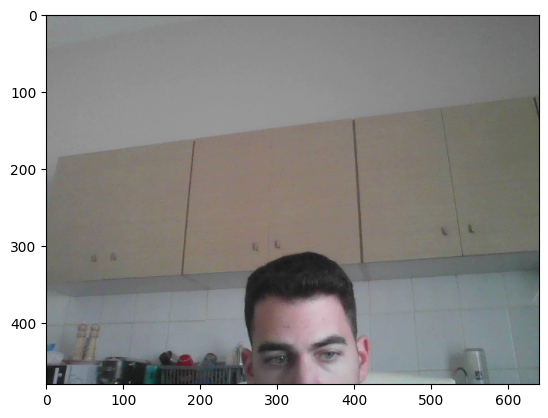

In [ ]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [ ]:
results.pose_landmarks

landmark {
  x: 0.53580749
  y: 0.96923995
  z: -1.25915122
  visibility: 0.950769544
}
landmark {
  x: 0.563376784
  y: 0.913251638
  z: -1.2020632
  visibility: 0.945886731
}
landmark {
  x: 0.578132927
  y: 0.909671426
  z: -1.20237136
  visibility: 0.95416832
}
landmark {
  x: 0.589199781
  y: 0.906825066
  z: -1.20244265
  visibility: 0.952638447
}
landmark {
  x: 0.510231912
  y: 0.918864548
  z: -1.22153103
  visibility: 0.943732679
}
landmark {
  x: 0.490781
  y: 0.918411672
  z: -1.22138512
  visibility: 0.943983376
}
landmark {
  x: 0.472735107
  y: 0.918061793
  z: -1.22189581
  visibility: 0.940834582
}
landmark {
  x: 0.606198788
  y: 0.918228149
  z: -0.748094618
  visibility: 0.958715379
}
landmark {
  x: 0.448679149
  y: 0.928997219
  z: -0.827142596
  visibility: 0.951305449
}
landmark {
  x: 0.56798178
  y: 1.01375592
  z: -1.07692933
  visibility: 0.884463251
}
landmark {
  x: 0.502546668
  y: 1.01473355
  z: -1.09918463
  visibility: 0.882436931
}
landmark {
  x: 0.